In [41]:
from datetime import datetime
import pandas as pd
import matplotlib.dates as mdates
import matplotlib as mpl
import matplotlib.pyplot as plt
from meteostat import Point, Hourly, Stations
from tqdm import tqdm
import sys
import numpy as np

In [42]:
sys.path.append('Utils/')
from PlotUtils import setMplParam, getColour, getHistoParam 
# getHistoParam: 
# Nbins, binwidth, bins, counts, bin_centers  = 
# from ExternalFunctions import nice_string_output, add_text_to_ax
setMplParam()
from DataPipelineWorkShop import get_hourly_example, MeteoPreprocessor

In [43]:
def make_single_window_dataframe(location: Point, 
                                 start_time: datetime, 
                                 horizon_hours: int) -> pd.DataFrame:
    """
    Construct a minimal Meteostat dataframe covering exactly one forecasting window.

    Args:
        location (Point): Meteostat location object.
        start_time (datetime): End of the observation window (the forecast will start right after this).
        exp_ctx (ExperimentContext): Contains forecast.window and forecast.horizon.
    """

    # Fetch data covering just enough history for one forecast
    history_end  = start_time + pd.Timedelta(hours=horizon_hours)

    df = get_hourly_example(location, start_time, history_end)
    df = df[df.index < history_end]

    # Defensive timestamp conversion
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp()

    return df

In [44]:
kbh = Point(lat=55.6761, lon=12.5683)
start_time = datetime(2019, 6, 3, 0, 0)
df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=12)

In [45]:
df_true.columns

Index(['temp', 'dwpt', 'rhum', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt', 'pres',
       'tsun', 'coco'],
      dtype='object')

In [46]:
df_true[['temp', 'rhum', 'prcp', 'wdir', 'wspd']]

,temp,rhum,prcp,wdir,wspd
time,,,,,
2019-06-03 00:00:00,16.0,71.0,0.0,130.0,25.9
2019-06-03 01:00:00,15.7,77.0,<NA>,140.0,27.7
2019-06-03 02:00:00,16.3,81.0,<NA>,140.0,22.3
2019-06-03 03:00:00,16.1,82.0,<NA>,150.0,16.6
2019-06-03 04:00:00,15.9,84.0,<NA>,150.0,11.2
2019-06-03 05:00:00,17.4,78.0,<NA>,200.0,11.2
2019-06-03 06:00:00,17.4,78.0,0.0,190.0,13.0
2019-06-03 07:00:00,18.9,74.0,<NA>,190.0,16.6
2019-06-03 08:00:00,20.5,71.0,<NA>,180.0,13.0


In [47]:
base = "/Users/yhjo/Desktop/[2025] Be Resilient/Resilience/"
prediction_files = {
    # "b256_d64_h2_l2_win24_ho12_lr1e-4" : base+"logs/20251110/153321/predictions/20251113_131644_epochepoch-19-val_lossval_loss-0.1044.csv",
    # "b256_d64_h2_l4_win24_ho12_lr1e-4" : base+"logs/20251110/141108/predictions/20251113_130918_epochepoch-19-valloss-0.1025.csv",
    # "b512_d64_h2_l4_win24_ho12_lr1e-4": base+"prediction/20251114/132736/20251114_144422_epoch-19-val_loss-0.1254.csv",
    # "b512_d64_h2_l4_win24_ho12_lr3e-4": base+"prediction/20251114/144305/20251114_180636_epoch-16-val_loss-0.0983.csv",
    # "b512_d64_h2_l4_win24_ho12_lr5e-4" : base+"prediction/20251114/114050/20251114_124824_epoch-15-val_loss-0.0957.csv",
    # "b512_d64_h2_l4_win24_ho12_lr7.5e-4" : base+"prediction/20251114/123713/20251114_132744_epoch-10-val_loss-0.0958.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100": base+"prediction/20251116/014137/20251117_123811_epoch-13-val_loss-0.0811.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_100_last": base+"prediction/20251116/014137/20251117_123835_last.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50": base+"prediction/20251116/201436/20251117_125436_epoch-27-val_loss-0.0836.csv",
    "b512_d64_h2_l4_win72_ho12_lr3e-4_50_last": base+"prediction/20251116/201436/20251117_125508_last.csv",
    
}

In [48]:
# df_pred = pd.read_csv(prediction_files["b256_d64_h2_l4_win24_ho12_lr1e-4"])
# df_pred.columns

In [49]:
processor = MeteoPreprocessor()
df_pred_inv = processor.inverse_transform(df_pred)

In [50]:
df_pred_inv

,time,temp,rhum,prcp,wspd,wdir
0,2019-06-03 00:00:00,13.769457,83.235651,0.021877,11.448321,204.952406
1,2019-06-03 01:00:00,14.292303,82.656369,0.012825,11.461506,206.955053
2,2019-06-03 02:00:00,13.421953,84.650454,0.013072,11.008427,215.998777
3,2019-06-03 03:00:00,13.523643,84.709540,0.002987,11.031719,218.716533
4,2019-06-03 04:00:00,13.608168,83.481392,-0.003813,11.377227,216.913380
5,2019-06-03 05:00:00,14.087631,82.520941,-0.011628,11.732664,215.207071
6,2019-06-03 06:00:00,14.701033,79.310396,-0.016595,12.996085,201.816883
7,2019-06-03 07:00:00,15.204529,77.170813,-0.027558,13.317376,206.139988
8,2019-06-03 08:00:00,15.800557,73.335299,-0.033467,14.302667,195.739123
9,2019-06-03 09:00:00,16.457846,70.005326,-0.030759,15.331733,192.898197


In [51]:
def plot_hourly_features(
    df_true: pd.DataFrame,
    df_pred: pd.DataFrame,
    features: list[str] = ['temp', 'rhum', 'wspd', 'wdir'],
    titles: list[str] = None
) -> None:
    # --- normalise time index for df_true ---
    if 'time' in df_true.columns:
        df_true['time'] = pd.to_datetime(df_true['time'])
        df_true = df_true.set_index('time')
    elif isinstance(df_true.index, pd.PeriodIndex):
        df_true.index = df_true.index.to_timestamp()

    # --- normalise time index for df_pred ---
    if 'time' in df_pred.columns:
        df_pred['time'] = pd.to_datetime(df_pred['time'])
        df_pred = df_pred.set_index('time')
    elif isinstance(df_pred.index, pd.PeriodIndex):
        df_pred.index = df_pred.index.to_timestamp()

    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=(19, 5*n_features), sharex=True)
    if n_features == 1:
        axes = [axes]
        
    for i, ax, feature in zip(range(n_features), axes, features):
        df_true[feature].plot(ax=ax, label="True")
        df_pred[feature].plot(ax=ax, label="Predicted", color=getColour(i+1))
        ax.set_title(
            titles[i] if titles is not None else feature
        )
        ax.set_ylabel(feature)
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


# plot_hourly_features(df_true, df_pred_inv, 
#                      features=['temp', 'rhum', 'wspd', 'wdir'], 
#                      titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)'])

In [52]:
def compare_models_per_feature(
    prediction_files: dict[str, str],
    features: list[str] = ['temp', 'rhum', 'wspd', 'wdir'],
    titles: list[str] = None,
    horizon_hours: int = 12,
    location: tuple[float, float] = (55.6761, 12.5683),
    start_time: datetime = datetime(2019, 6, 3, 0, 0)
):
    """
    For each feature, plot True vs predictions from all models in one figure.
    """
    # --- Prepare true data once ---
    lat, lon = location
    kbh = Point(lat=lat, lon=lon)
    df_true = make_single_window_dataframe(
        kbh, start_time,
        horizon_hours=horizon_hours
    )
    
    if "time" in df_true.columns:
        df_true["time"] = pd.to_datetime(df_true["time"])
        df_true = df_true.set_index("time")
    
    processor = MeteoPreprocessor()
    
    # --- Pre-load all predictions ---
    preds = {}
    for model_name, file_path in prediction_files.items():
        df_pred = pd.read_csv(file_path)
        df_pred = processor.inverse_transform(df_pred)
        
        if "time" in df_pred.columns:
            df_pred["time"] = pd.to_datetime(df_pred["time"])
            df_pred = df_pred.set_index("time")

        preds[model_name] = df_pred

    # --- Plot feature-by-feature ---
    for idx, feature in enumerate(features):

        # ============================================
        # SPECIAL CASE: WIND DIRECTION (POLAR PLOT)
        # ============================================
        if feature == "wdir":
            times = df_true.index
            num_models = len(preds) + 1  # True + models

            fig, ax = plt.subplots(figsize=(18, 2 + num_models * 1.0))

            # spacing for rows
            row_positions = np.arange(num_models)

            # --- helper to draw arrows at a fixed y position ---
            def plot_direction_row(y, angles_deg, color, label):
                angles = np.deg2rad(angles_deg)

                L = 0.08      # constant arrow length

                dx = L * np.cos(angles)
                dy = L * np.sin(angles)

                ax.quiver(
                    times,
                    np.full(len(times), y),
                    dx,
                    dy,
                    color=color,
                    label=label,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=0.006,
                    headwidth=3,
                    headlength=4,
                    headaxislength=3,
                )

            # After plotting all rows
            ax.set_ylim(-1, num_models)
            ax.set_xlim(times.min(), times.max())
            # ax.set_aspect("equal", adjustable="box")



            # True at row 0
            plot_direction_row(row_positions[0], df_true["wdir"].values, "black", "True")

            # Models at rows 1, 2, 3...
            for i, (model_name, df_pred) in enumerate(preds.items(), start=1):
                plot_direction_row(row_positions[i], df_pred["wdir"].values, getColour(i), model_name)

            # formatting
            ax.set_ylim(-1, num_models)
            ax.set_yticks(row_positions)
            ax.set_yticklabels(["True"] + list(preds.keys()))
            ax.set_title("Wind Direction (Arrow Timeline)")
            ax.set_xlabel("Time")
            ax.grid(axis="x", linestyle="--", alpha=0.3)

            plt.tight_layout()
            plt.show()
            # continue


        # ============================================
        # NORMAL LINE PLOT FOR NON-ANGULAR FEATURES
        # ============================================
        fig, ax = plt.subplots(figsize=(18, 6))

        df_true[feature].plot(ax=ax, label="True", linewidth=2, color='black')

        for i, (model_name, df_pred) in enumerate(preds.items()):
            df_pred[feature].plot(
                ax=ax,
                label=f"{model_name}",
                color=getColour(i)
            )

        ax.set_title(titles[idx] if titles else feature)
        ax.set_ylabel(feature)
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()
        plt.show()


In [53]:
def compare_models_per_feature(
    prediction_files: dict[str, str],
    features: list[str] = ['temp', 'rhum', 'wspd', 'wdir'],
    titles: list[str] = None,
    horizon_hours: int = 12,
    location: tuple[float, float] = (55.6761, 12.5683),
    start_time: datetime = datetime(2019, 6, 3, 0, 0)
):

    # ------------------------------------------------------------
    # Load TRUE data
    # ------------------------------------------------------------
    lat, lon = location
    kbh = Point(lat=lat, lon=lon)
    df_true = make_single_window_dataframe(kbh, start_time, horizon_hours=horizon_hours)

    if "time" in df_true.columns:
        df_true["time"] = pd.to_datetime(df_true["time"])
        df_true = df_true.set_index("time")

    processor = MeteoPreprocessor()

    # ------------------------------------------------------------
    # Load MODEL predictions
    # ------------------------------------------------------------
    preds = {}
    for model_name, file_path in prediction_files.items():
        df_pred = pd.read_csv(file_path)
        df_pred = processor.inverse_transform(df_pred)

        if "time" in df_pred.columns:
            df_pred["time"] = pd.to_datetime(df_pred["time"])
            df_pred = df_pred.set_index("time")

        preds[model_name] = df_pred

    # ------------------------------------------------------------
    # Plot features
    # ------------------------------------------------------------
    for idx, feature in enumerate(features):

        # ==========================
        # SPECIAL CASE: WIND DIR
        # ==========================
        if feature == "wdir":
            times = df_true.index
            n_steps = len(times)

            # use integer positions for x (0,1,2,...) to avoid datetime scaling hell
            x_idx = np.arange(n_steps)

            num_models = len(preds) + 1  # True + models
            row_positions = np.arange(num_models)

            fig, ax = plt.subplots(figsize=(18, 2 + num_models * 1.0))

            def plot_direction_row(y, angles_deg, color, label=None):
                angles = np.deg2rad(angles_deg)

                # fixed arrow length in this nice, almost-square coordinate system
                L = 0.4  # tweak to taste
                dx = L * np.cos(angles)
                dy = L * np.sin(angles)

                ax.quiver(
                    x_idx,
                    np.full_like(x_idx, y, dtype=float),
                    dx,
                    dy,
                    angles='xy',
                    scale_units='xy',
                    scale=1,
                    width=0.005,
                    headwidth=3,
                    headlength=3,
                    headaxislength=2,
                    color=color,
                    label=label,
                )

            # True at row 0
            plot_direction_row(row_positions[0], df_true["wdir"].values, "black", "True")

            # Models at rows 1, 2, ...
            for i, (model_name, df_pred) in enumerate(preds.items(), start=1):
                plot_direction_row(row_positions[i], df_pred["wdir"].values, getColour(i-1), model_name)

            # y-axis labels = True + model names
            ax.set_ylim(-1, num_models)
            ax.set_yticks(row_positions)
            ax.set_yticklabels(["True"] + list(preds.keys()))

            # x-axis: show times as tick labels
            ax.set_xticks(x_idx)
            ax.set_xticklabels(
                [t.strftime("%Y-%m-%d %H:%M") for t in times],
                rotation=45,
                ha="right"
            )

            ax.set_title("Wind Direction (Arrow Timeline)")
            ax.set_xlabel("Time")
            ax.grid(axis="x", linestyle="--", alpha=0.3)
            ax.invert_yaxis()

            plt.tight_layout()
            plt.show()

        # ==========================
        # NORMAL LINE PLOTS
        # ==========================
        fig, ax = plt.subplots(figsize=(18, 6))

        df_true[feature].plot(ax=ax, label="True", linewidth=2, color="black")
        for i, (model_name, df_pred) in enumerate(preds.items()):
            df_pred[feature].plot(ax=ax, label=model_name, color=getColour(i))

        ax.set_title(titles[idx] if titles else feature)
        ax.set_ylabel(feature)
        ax.set_xlabel("Date")
        ax.legend()
        plt.tight_layout()
        plt.show()


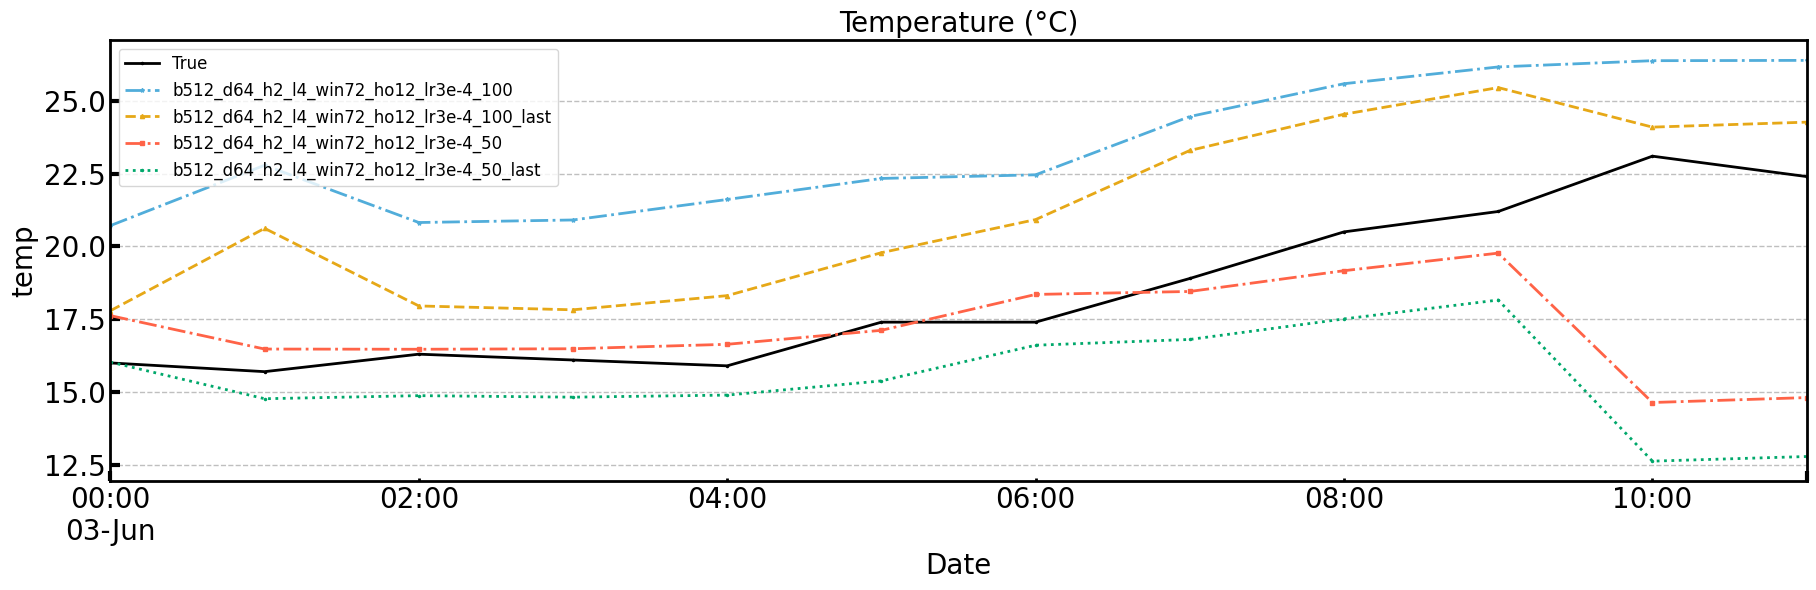

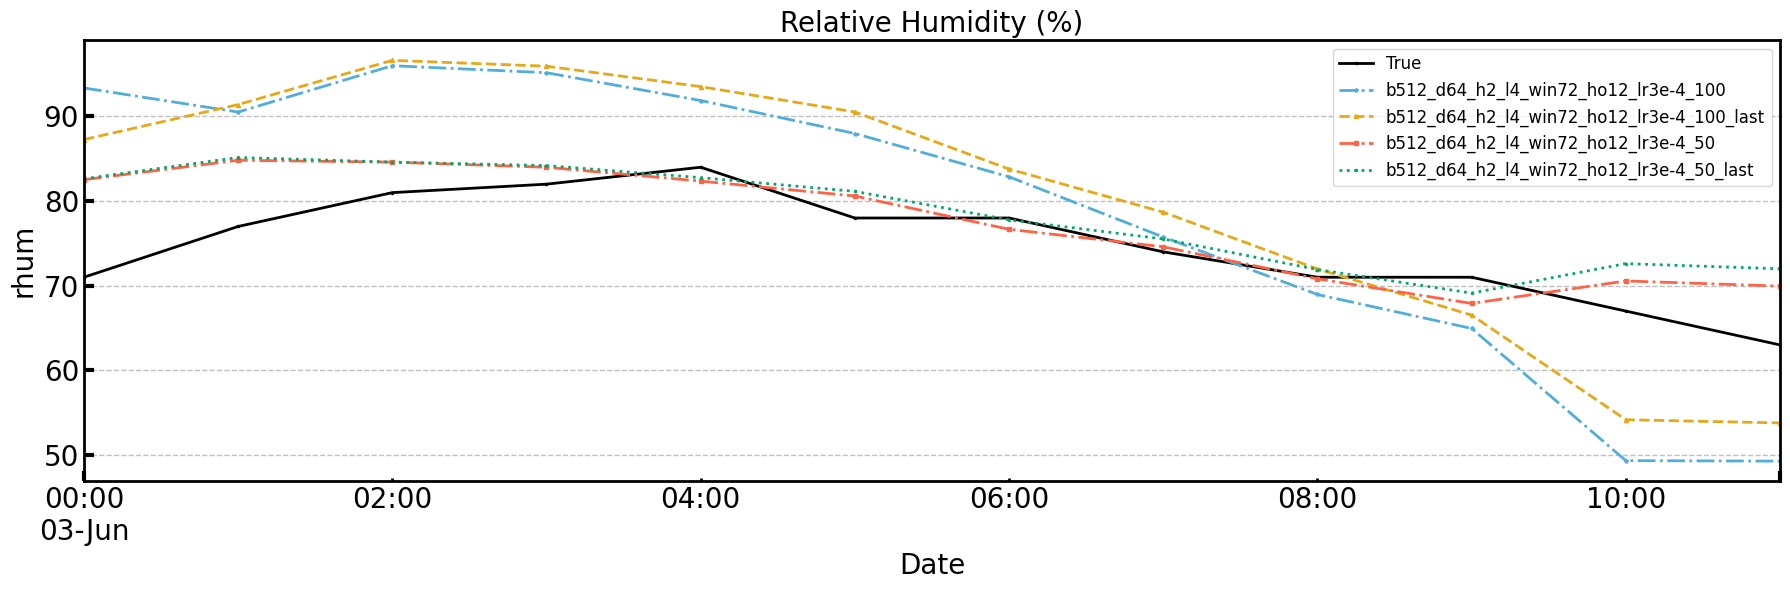

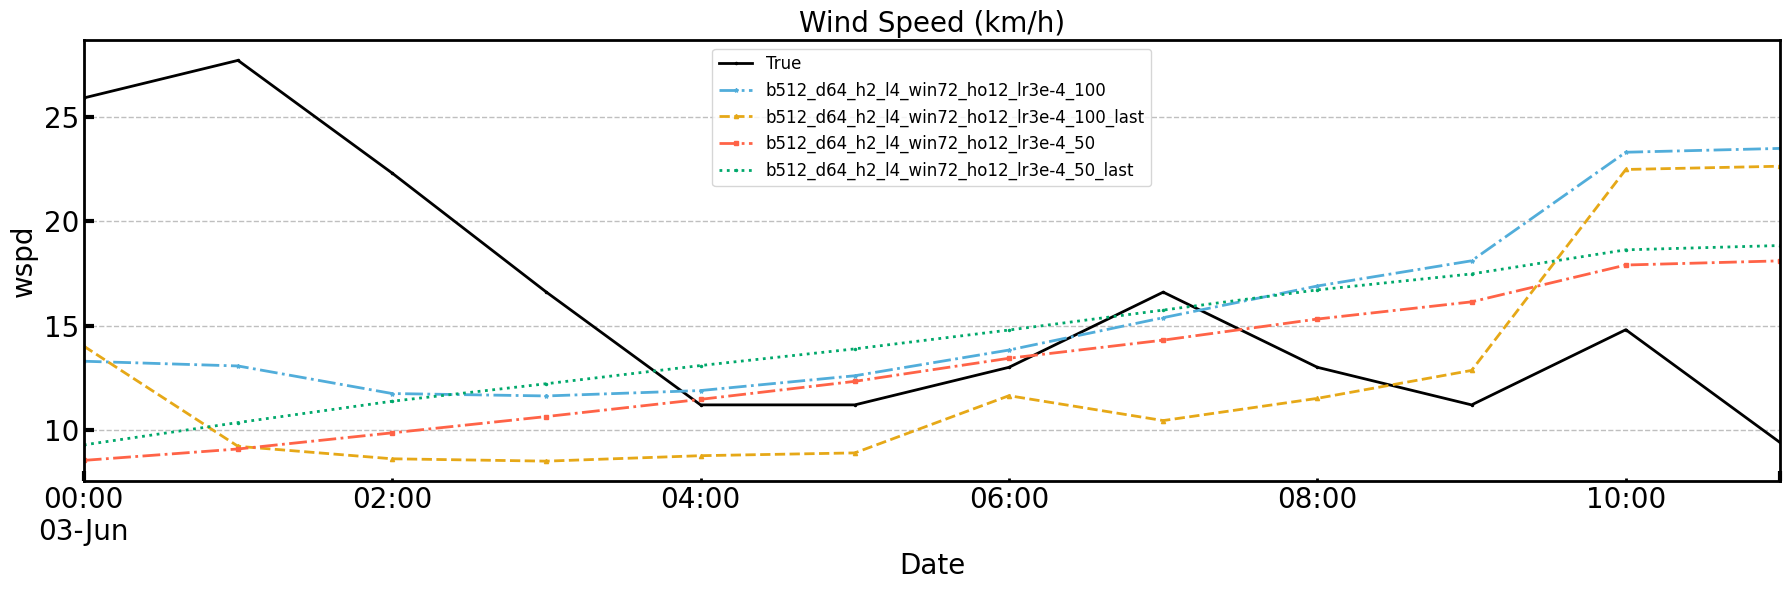

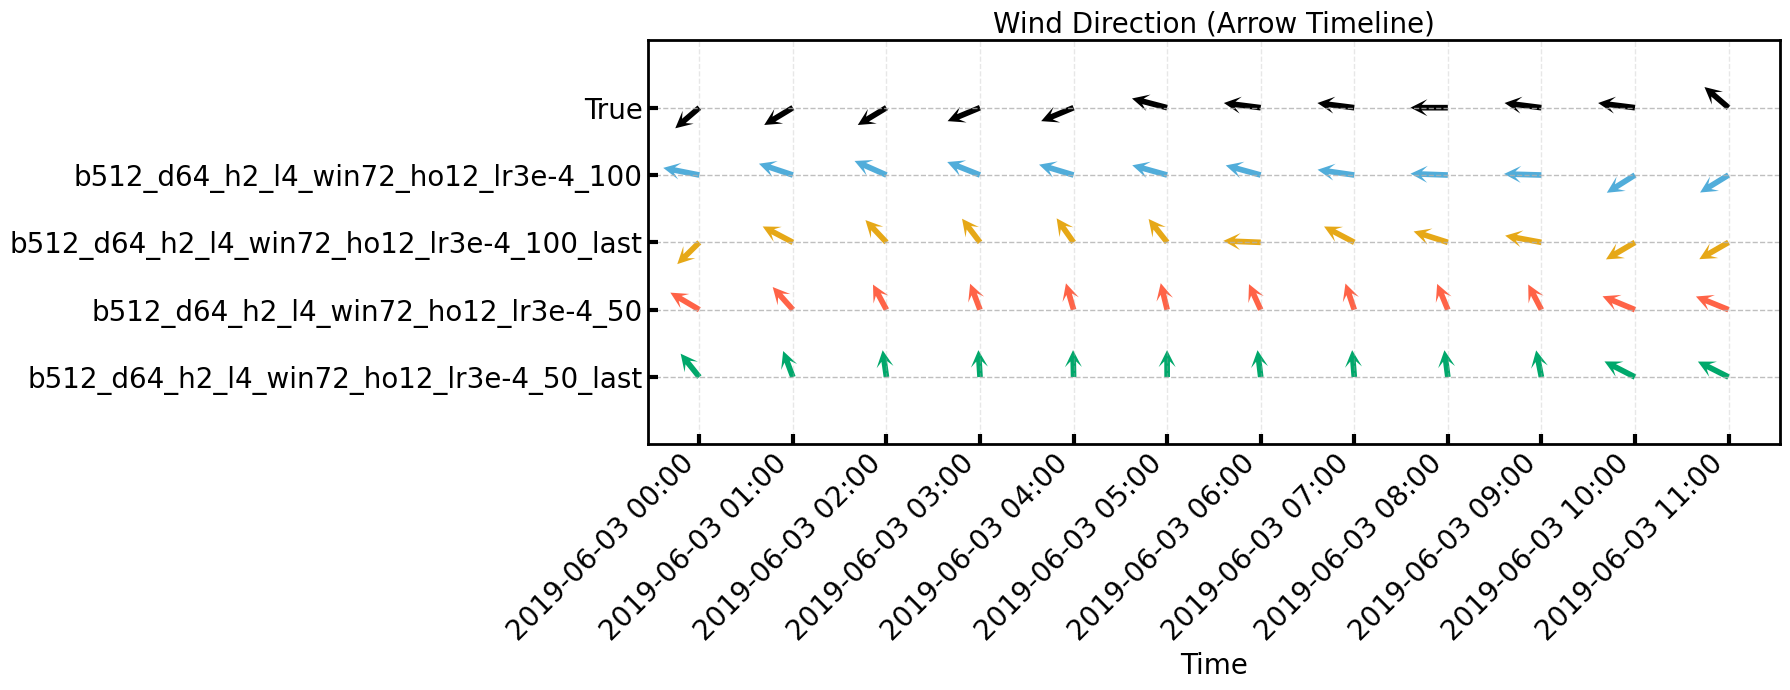

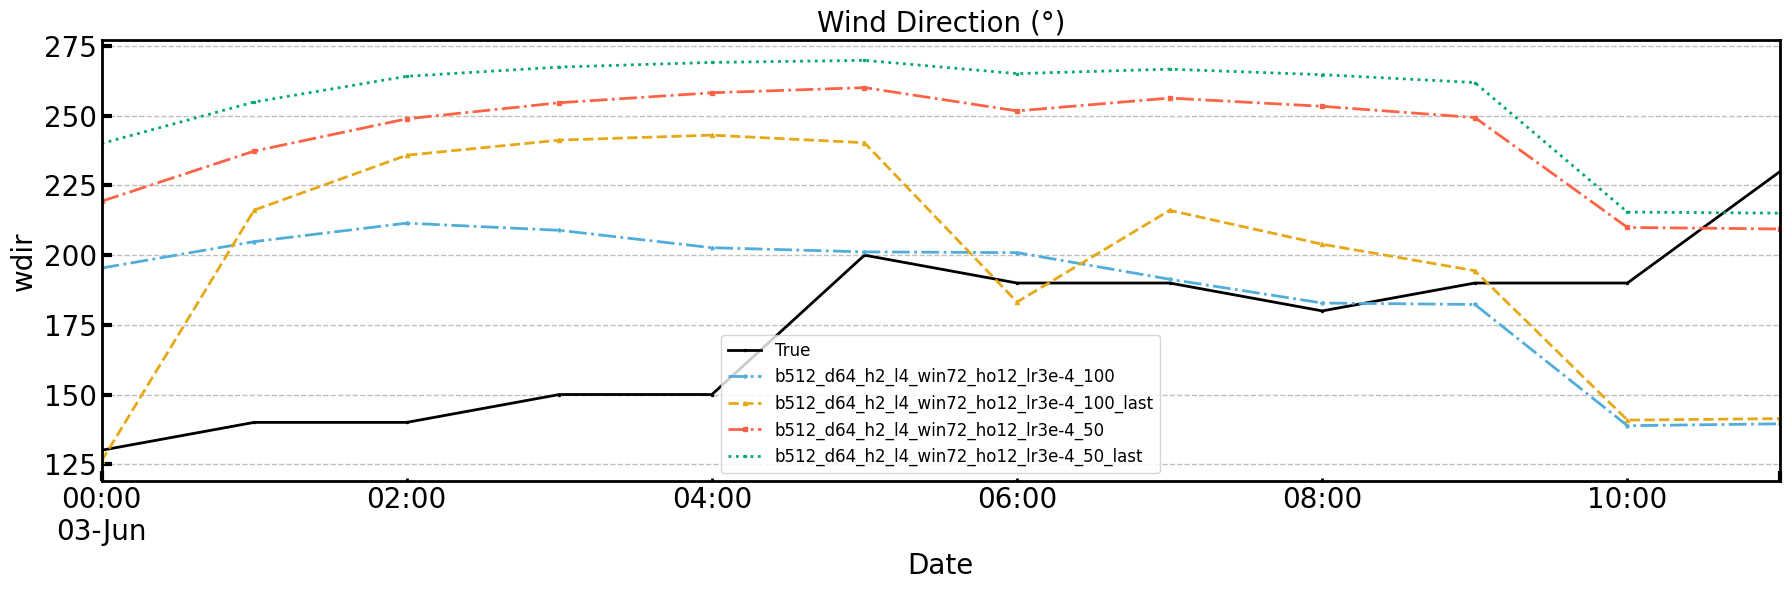

In [54]:
compare_models_per_feature(
    prediction_files,
    features=['temp', 'rhum', 'wspd', 'wdir'],
    titles=['Temperature (°C)', 'Relative Humidity (%)', 'Wind Speed (km/h)', 'Wind Direction (°)']
)